# Comparación final de modelos e interpretación de resultados

## Objetivos 

En esta sesión se busca:

1. Integrar los principales resultados obtenidos en el proyecto.
2. Comparar de forma consolidada los modelos estudiados:
   - regresión logística,
   - árbol de decisión,
   - Random Forest.
3. Identificar el modelo más adecuado para este problema.
4. Resumir las variables más relevantes para la predicción de incumplimiento.
5. Elaborar conclusiones finales desde el punto de vista estadístico y sustantivo.

## Contexto

A lo largo del proyecto se exploró el dataset, se depuraron variables, se construyó un baseline con regresión logística, se comparó con modelos basados en árboles y finalmente se evaluó no sólo la capacidad discriminante, sino también la calibración de probabilidades.

En esta última sesión se busca consolidar toda esa evidencia para responder de manera clara qué modelo funciona mejor, qué variables parecen más importantes y qué conclusiones pueden extraerse sobre el riesgo de incumplimiento en este conjunto de datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [4]:
df = pd.read_csv("default_credit_clean.csv")

if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default_next_month"})

if "AGE_GROUP" not in df.columns:
    bins = [20, 30, 40, 50, 60, 80]
    labels = ["20-29", "30-39", "40-49", "50-59", "60+"]
    df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:10])
df.head()

Dimensiones del dataset: (30000, 29)

Primeras columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59


In [5]:
cols_to_drop = ["default_next_month"]
optional_drop = ["ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"]

for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Columnas de X:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción de incumplimiento en y_train:", y_train.mean())
print("Proporción de incumplimiento en y_test :", y_test.mean())

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)

Proporción de incumplimiento en y_train: 0.22120833333333334
Proporción de incumplimiento en y_test : 0.22116666666666668


In [8]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nNúmero de variables categóricas:", len(categorical_features))

print("\nVariables numéricas:")
print(numeric_features)

print("\nNúmero de variables numéricas:", len(numeric_features))

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

Número de variables categóricas: 4

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Número de variables numéricas: 20


## Preprocesamiento para la regresión logística

La regresión logística requiere que las variables numéricas estén en escalas comparables. Por ello, se definirá un pipeline con:

- **variables numéricas**:
  - imputación por mediana,
  - escalamiento estandarizado;

- **variables categóricas**:
  - imputación por la categoría más frecuente,
  - codificación `one-hot`.

Este preprocesamiento será usado únicamente para la regresión logística.

In [9]:
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer_lr, categorical_features)
    ]
)

print(preprocessor_lr)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  

## Preprocesamiento para el árbol de decisión y Random Forest

Tanto el árbol de decisión como Random Forest no requieren escalamiento de las variables numéricas. Sin embargo, sí conviene:

- imputar valores faltantes,
- y codificar las variables categóricas.

Por ello, se construirá un pipeline común para ambos modelos, sin incluir `StandardScaler`.

In [10]:
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer_tree, categorical_features)
    ]
)

print(preprocessor_tree)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                   

## Entrenamiento de los tres modelos

En esta sección se entrenarán nuevamente los tres modelos estudiados en el proyecto:

- **regresión logística**,
- **árbol de decisión**,
- **Random Forest**.

El objetivo es generar una comparación final consolidada de desempeño, calibración e interpretación.

In [11]:
# Regresión logística
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

# Árbol de decisión
tree_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Random Forest
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE',
                                                   'AGE_GROUP'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## Predicciones y probabilidades de los tres modelos

Para construir la comparación final, se obtendrán:

- predicciones de clase,
- y probabilidades estimadas de incumplimiento,

en el conjunto de prueba para los tres modelos.

In [12]:
# Regresión logística
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Árbol de decisión
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Primeras 10 probabilidades de regresión logística:")
print(y_proba_lr[:10])

print("\nPrimeras 10 probabilidades del árbol de decisión:")
print(y_proba_tree[:10])

print("\nPrimeras 10 probabilidades de Random Forest:")
print(y_proba_rf[:10])

Primeras 10 probabilidades de regresión logística:
[0.10806998 0.11724991 0.2223453  0.09658985 0.02977732 0.21014218
 0.13061203 0.15772985 0.0784884  0.19577078]

Primeras 10 probabilidades del árbol de decisión:
[0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]

Primeras 10 probabilidades de Random Forest:
[0.155 0.215 0.21  0.18  0.015 0.415 0.09  0.    0.09  0.04 ]



Las primeras probabilidades estimadas vuelven a mostrar diferencias importantes entre los modelos:

### Regresión logística
La regresión logística produce **probabilidades continuas y graduales**, con valores relativamente bajos en estos primeros casos. Esto es consistente con su naturaleza probabilística y con una estimación suave del riesgo.

### Árbol de decisión
El árbol de decisión produce probabilidades **extremas**, en este ejemplo `0` o `1`. Este comportamiento refleja una de sus principales limitaciones: sus probabilidades son más bruscas y menos refinadas.

### Random Forest
Random Forest produce probabilidades **continuas pero más estables** que las del árbol individual. Al promediar muchos árboles, el ensamble suaviza las predicciones y reduce la brusquedad observada en el árbol de decisión.

En conjunto, esta comparación anticipa uno de los hallazgos principales del proyecto: Random Forest no sólo mejora al árbol individual en desempeño global, sino también en la calidad y estabilidad de las probabilidades estimadas.

## Tabla comparativa final de métricas

En esta sección se consolidarán en una sola tabla las métricas principales de los tres modelos:

- `accuracy`
- `precision`
- `recall`
- `F1-score`
- `ROC-AUC`
- `Brier score`

Además, se calcularán rankings para identificar con mayor claridad qué modelo tuvo mejor desempeño en:

- capacidad discriminante,
- calidad probabilística.

In [13]:
def resumen_modelo(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba)
    }

tabla_final = pd.DataFrame({
    "Logistic Regression": resumen_modelo(y_test, y_pred_lr, y_proba_lr),
    "Decision Tree": resumen_modelo(y_test, y_pred_tree, y_proba_tree),
    "Random Forest": resumen_modelo(y_test, y_pred_rf, y_proba_rf)
}).T

tabla_final["rank_roc_auc"] = tabla_final["roc_auc"].rank(ascending=False, method="min")
tabla_final["rank_brier"] = tabla_final["brier_score"].rank(ascending=True, method="min")
tabla_final["rank_f1"] = tabla_final["f1"].rank(ascending=False, method="min")

tabla_final

,accuracy,precision,recall,f1,roc_auc,brier_score,rank_roc_auc,rank_brier,rank_f1
Logistic Regression,0.8085,0.6894,0.2442,0.3606,0.7102,0.1466,2.0000,2.0000,3.0000
Decision Tree,0.7162,0.3672,0.3919,0.3791,0.6005,0.2837,3.0000,3.0000,2.0000
Random Forest,0.8127,0.6327,0.3647,0.4627,0.7575,0.1394,1.0000,1.0000,1.0000




La tabla final resume de manera muy clara el desempeño de los tres modelos en las principales métricas del proyecto.

### Regresión logística
La regresión logística mostró:

- buen **accuracy**,
- la **mayor precision**,
- pero el **menor recall**,
- además de un `ROC-AUC` y un `Brier score` competitivos, aunque no los mejores.

Esto confirma que se trata de un modelo **conservador**: cuando predice incumplimiento suele acertar, pero deja escapar muchos casos positivos.

### Árbol de decisión
El árbol de decisión obtuvo:

- el peor **accuracy**,
- la peor **precision**,
- el peor **ROC-AUC**,
- y el peor **Brier score**.

Aunque su `recall` fue el mayor entre los tres, su desempeño global resultó claramente inferior. Esto indica que detecta más incumplimientos, pero a costa de demasiados errores y probabilidades poco confiables.

### Random Forest
Random Forest obtuvo:

- el mejor **accuracy**,
- el mejor **F1-score**,
- el mejor **ROC-AUC**,
- y el mejor **Brier score**.

Además, logró un `recall` mayor que la regresión logística sin deteriorar tanto la `precision` como lo hizo el árbol de decisión.

### Interpretación general
Los rankings muestran que **Random Forest** ocupa el **primer lugar** en:

- capacidad discriminante (`ROC-AUC`),
- calidad probabilística (`Brier score`),
- y equilibrio entre precision y recall (`F1-score`).

Esto sugiere que, entre los modelos estudiados, **Random Forest fue el modelo más sólido y balanceado** para este problema.

## Visualización comparativa de métricas

Para facilitar la interpretación de la tabla final, se construirá una gráfica de barras con algunas métricas clave:

- `accuracy`
- `precision`
- `recall`
- `F1-score`
- `ROC-AUC`

Esto permitirá comparar visualmente el comportamiento de los tres modelos.

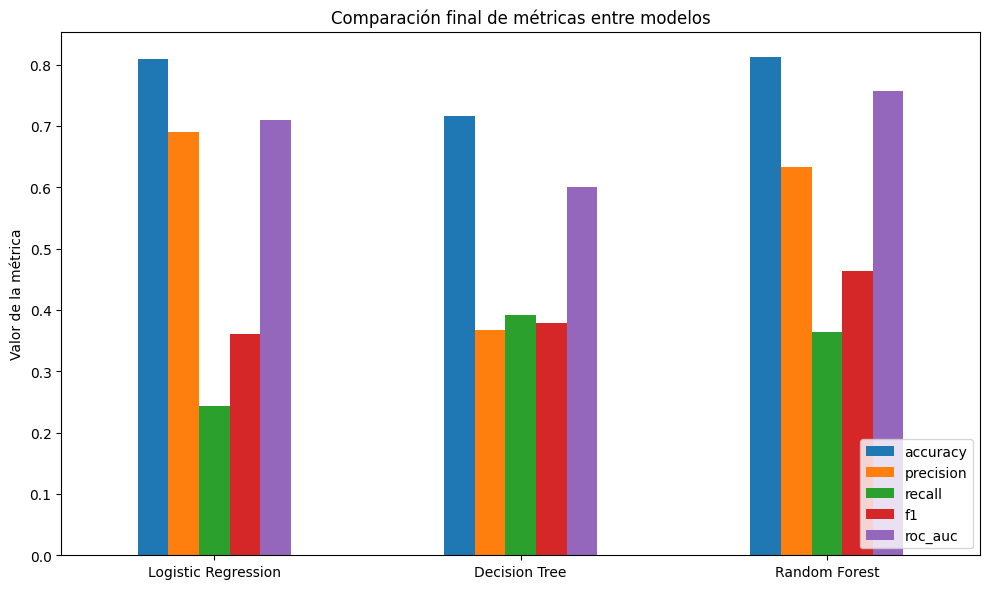

In [15]:
metricas_plot = tabla_final[["accuracy", "precision", "recall", "f1", "roc_auc"]]

metricas_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Comparación final de métricas entre modelos")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



La gráfica de barras permite sintetizar visualmente el comportamiento de los tres modelos.

### Regresión logística
Se observa que la regresión logística destaca por su **precision** alta, pero su **recall** es claramente más bajo que el de los otros modelos. Esto confirma su carácter conservador: predice incumplimiento con bastante cuidado, pero deja pasar muchos casos positivos.

### Árbol de decisión
El árbol de decisión presenta el **recall** más alto, lo que indica que detecta una mayor proporción de incumplimientos reales. Sin embargo, sus barras de **accuracy**, **precision** y **ROC-AUC** son notablemente más bajas, lo que refleja un desempeño global inferior.

### Random Forest
Random Forest destaca por mantener valores altos y equilibrados en varias métricas al mismo tiempo:

- el mayor **accuracy**,
- el mayor **F1-score**,
- y el mayor **ROC-AUC**,

además de un `recall` superior al de la regresión logística y una `precision` mucho mejor que la del árbol de decisión.

### Interpretación general
La comparación visual refuerza la conclusión central del proyecto:

- la **regresión logística** es más precisa pero poco sensible,
- el **árbol de decisión** es más sensible pero menos estable,
- y **Random Forest** logra el mejor equilibrio entre ambos comportamientos.

Por ello, Random Forest aparece como la opción más sólida para este problema.

## Variables más importantes en Random Forest

Como el análisis final sugiere que Random Forest es el modelo más sólido, conviene revisar qué variables fueron más relevantes para sus predicciones.

Esto permitirá cerrar el proyecto no sólo identificando el mejor modelo, sino también destacando los principales factores asociados al riesgo de incumplimiento.

In [16]:
feature_names_num = numeric_features

ohe_rf = rf_clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe_rf.get_feature_names_out(categorical_features)

feature_names_rf = np.concatenate([feature_names_num, feature_names_cat])

importances_rf = rf_clf.named_steps["model"].feature_importances_

importance_rf_df = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False)

importance_rf_df.head(15)

,feature,importance
2,PAY_0,0.0976
0,LIMIT_BAL,0.0598
1,AGE,0.0593
8,BILL_AMT1,0.0580
9,BILL_AMT2,0.0523
14,PAY_AMT1,0.0499
10,BILL_AMT3,0.0495
11,BILL_AMT4,0.0495
12,BILL_AMT5,0.0493
13,BILL_AMT6,0.0492




Las variables más importantes en Random Forest confirman un patrón consistente con todo el análisis realizado a lo largo del proyecto.

La variable más influyente es:

- **`PAY_0`**, con una importancia de **0.0976**.

Esto indica que el **estado de pago más reciente** es la señal más fuerte para anticipar incumplimiento futuro.

Después aparecen variables como:

- `LIMIT_BAL`,
- `AGE`,
- `BILL_AMT1`,
- `BILL_AMT2`,
- `PAY_AMT1`,
- y varios montos facturados y pagados.

### Interpretación sustantiva
En conjunto, estas variables sugieren que el riesgo de incumplimiento depende principalmente de una combinación entre:

1. **historial reciente de mora**,
2. **capacidad crediticia** reflejada por `LIMIT_BAL`,
3. **características generales del cliente**, como la edad,
4. **nivel reciente de deuda**,
5. y **comportamiento de pago previo**.

Esto es razonable desde un punto de vista aplicado: un cliente con atraso reciente, cierto nivel de endeudamiento y determinados patrones de pago previos tiene una mayor probabilidad de incumplimiento.

También es notable que las variables demográficas categóricas (`SEX`, `EDUCATION`, `MARRIAGE`) no aparecen entre las más influyentes, lo que sugiere que las variables financieras y de comportamiento de pago contienen la mayor parte de la señal predictiva.

## Visualización de las variables más importantes en Random Forest

Para facilitar la interpretación final, se representarán en una gráfica de barras las variables con mayor importancia en el modelo de Random Forest.

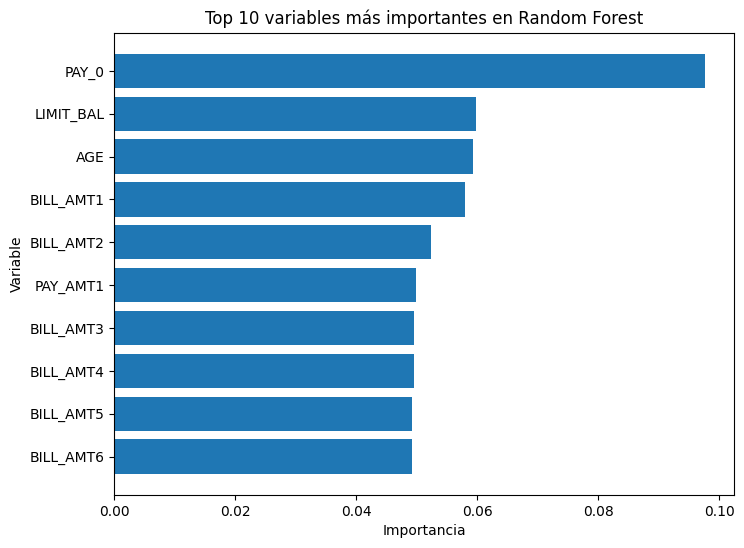

In [18]:
top_n = 10
top_features_rf = importance_rf_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features_rf["feature"], top_features_rf["importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 variables más importantes en Random Forest")
plt.show()


La gráfica confirma visualmente que **`PAY_0`** es la variable más influyente en Random Forest. Esto refuerza una conclusión que apareció de manera consistente a lo largo del proyecto: el **estado de pago más reciente** es la señal central para anticipar incumplimiento.

Después de `PAY_0`, aparecen con importancia similar:

- `LIMIT_BAL`,
- `AGE`,
- `BILL_AMT1`,
- `BILL_AMT2`,
- `PAY_AMT1`,
- y varios montos facturados recientes.

La gráfica muestra además que Random Forest distribuye la importancia de forma más balanceada entre varias variables, en lugar de depender excesivamente de una sola. Esto sugiere que el modelo aprovecha información complementaria de:

1. **historial reciente de pago**,
2. **capacidad crediticia**,
3. **edad del cliente**,
4. **niveles recientes de deuda**,
5. y **comportamiento de pago previo**.

En términos sustantivos, esto apoya la idea de que el riesgo de incumplimiento es un fenómeno multifactorial, donde las variables financieras y de comportamiento reciente contienen la mayor parte de la señal predictiva.

## Síntesis final del proyecto

A partir de todo el trabajo realizado en los ocho notebooks, se pueden resumir los hallazgos principales del proyecto de la siguiente manera:

1. El problema de incumplimiento de pago se abordó como un problema de **clasificación binaria**, donde el objetivo fue predecir la variable `default_next_month`.
2. El análisis exploratorio mostró que variables relacionadas con el **historial reciente de pago** tienen una asociación muy clara con el incumplimiento.
3. La depuración del dataset permitió construir una base analítica consistente, especialmente al recodificar categorías atípicas y distinguir entre variables numéricas, categóricas y ordinales.
4. La **regresión logística** funcionó como un baseline interpretable y estable, con buena precisión pero bajo recall.
5. El **árbol de decisión** permitió capturar relaciones no lineales, pero mostró menor estabilidad, peor discriminación y probabilidades poco calibradas.
6. **Random Forest** obtuvo el mejor desempeño global entre los modelos estudiados:
   - mayor `accuracy`,
   - mayor `F1-score`,
   - mayor `ROC-AUC`,
   - y menor `Brier score`.
7. Las variables más importantes en Random Forest fueron principalmente:
   - `PAY_0`,
   - `LIMIT_BAL`,
   - `AGE`,
   - y varios montos facturados y pagados.
8. En conjunto, el análisis sugiere que el riesgo de incumplimiento depende sobre todo de la combinación entre:
   - historial reciente de mora,
   - capacidad crediticia,
   - nivel de endeudamiento,
   - y comportamiento de pago previo.

## Conclusiones finales

En este proyecto se analizaron distintas estrategias para predecir incumplimiento de pago en el dataset **Default of Credit Card Clients**. A partir de la evidencia obtenida, se concluye lo siguiente:

- La **regresión logística** es una buena referencia inicial por su simplicidad, interpretabilidad y estabilidad.
- El **árbol de decisión** aporta una perspectiva no lineal, pero en su forma individual resultó menos competitivo tanto en discriminación como en calibración.
- **Random Forest** fue el modelo más sólido del estudio, al combinar:
  - mejor capacidad para distinguir entre clientes con y sin incumplimiento,
  - mejor equilibrio entre precision y recall,
  - y mejores probabilidades predichas en términos de Brier score.

Desde el punto de vista sustantivo, el proyecto mostró que el **historial reciente de pago** es la fuente de información más importante para anticipar incumplimiento, seguido por variables relacionadas con límite de crédito, edad, montos facturados y montos pagados.

En consecuencia, para este conjunto de datos, **Random Forest** puede considerarse la mejor alternativa entre los modelos evaluados, mientras que la regresión logística sigue siendo útil como baseline interpretable.

## Posibles extensiones

Como trabajo futuro, podrían explorarse temas como:

- ajuste de hiperparámetros,
- calibración adicional de probabilidades,
- validación cruzada,
- análisis de desbalance más profundo,
- o comparación con otros modelos de ensamble.